In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

IndentationError: expected an indented block after 'for' statement on line 13 (3687147546.py, line 21)

## Step 1 — Setup & Imports

In [1]:
# ============================================
# CELL 1: Import required libraries
# ============================================
import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dropout
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Dense, Embedding, LSTM, Concatenate, Add,
    RepeatVector, TimeDistributed, Attention, Reshape
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Fix seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Step 2 — Load Dataset

In [2]:
# ============================================
# CELL 2: Load images and captions
# ============================================
# Adjust this path once you add the dataset — check the "Input" panel on the right
BASE_DIR = "/kaggle/input/datasets/adityajn105/flickr8k"
IMAGES_DIR = os.path.join(BASE_DIR, "Images")
CAPTIONS_FILE = os.path.join(BASE_DIR, "captions.txt")

captions_df = pd.read_csv(CAPTIONS_FILE)
print("Total caption rows:", len(captions_df))
print("Unique images:", captions_df['image'].nunique())
captions_df.head()

Total caption rows: 40455
Unique images: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


## Step 3 — Quick EDA

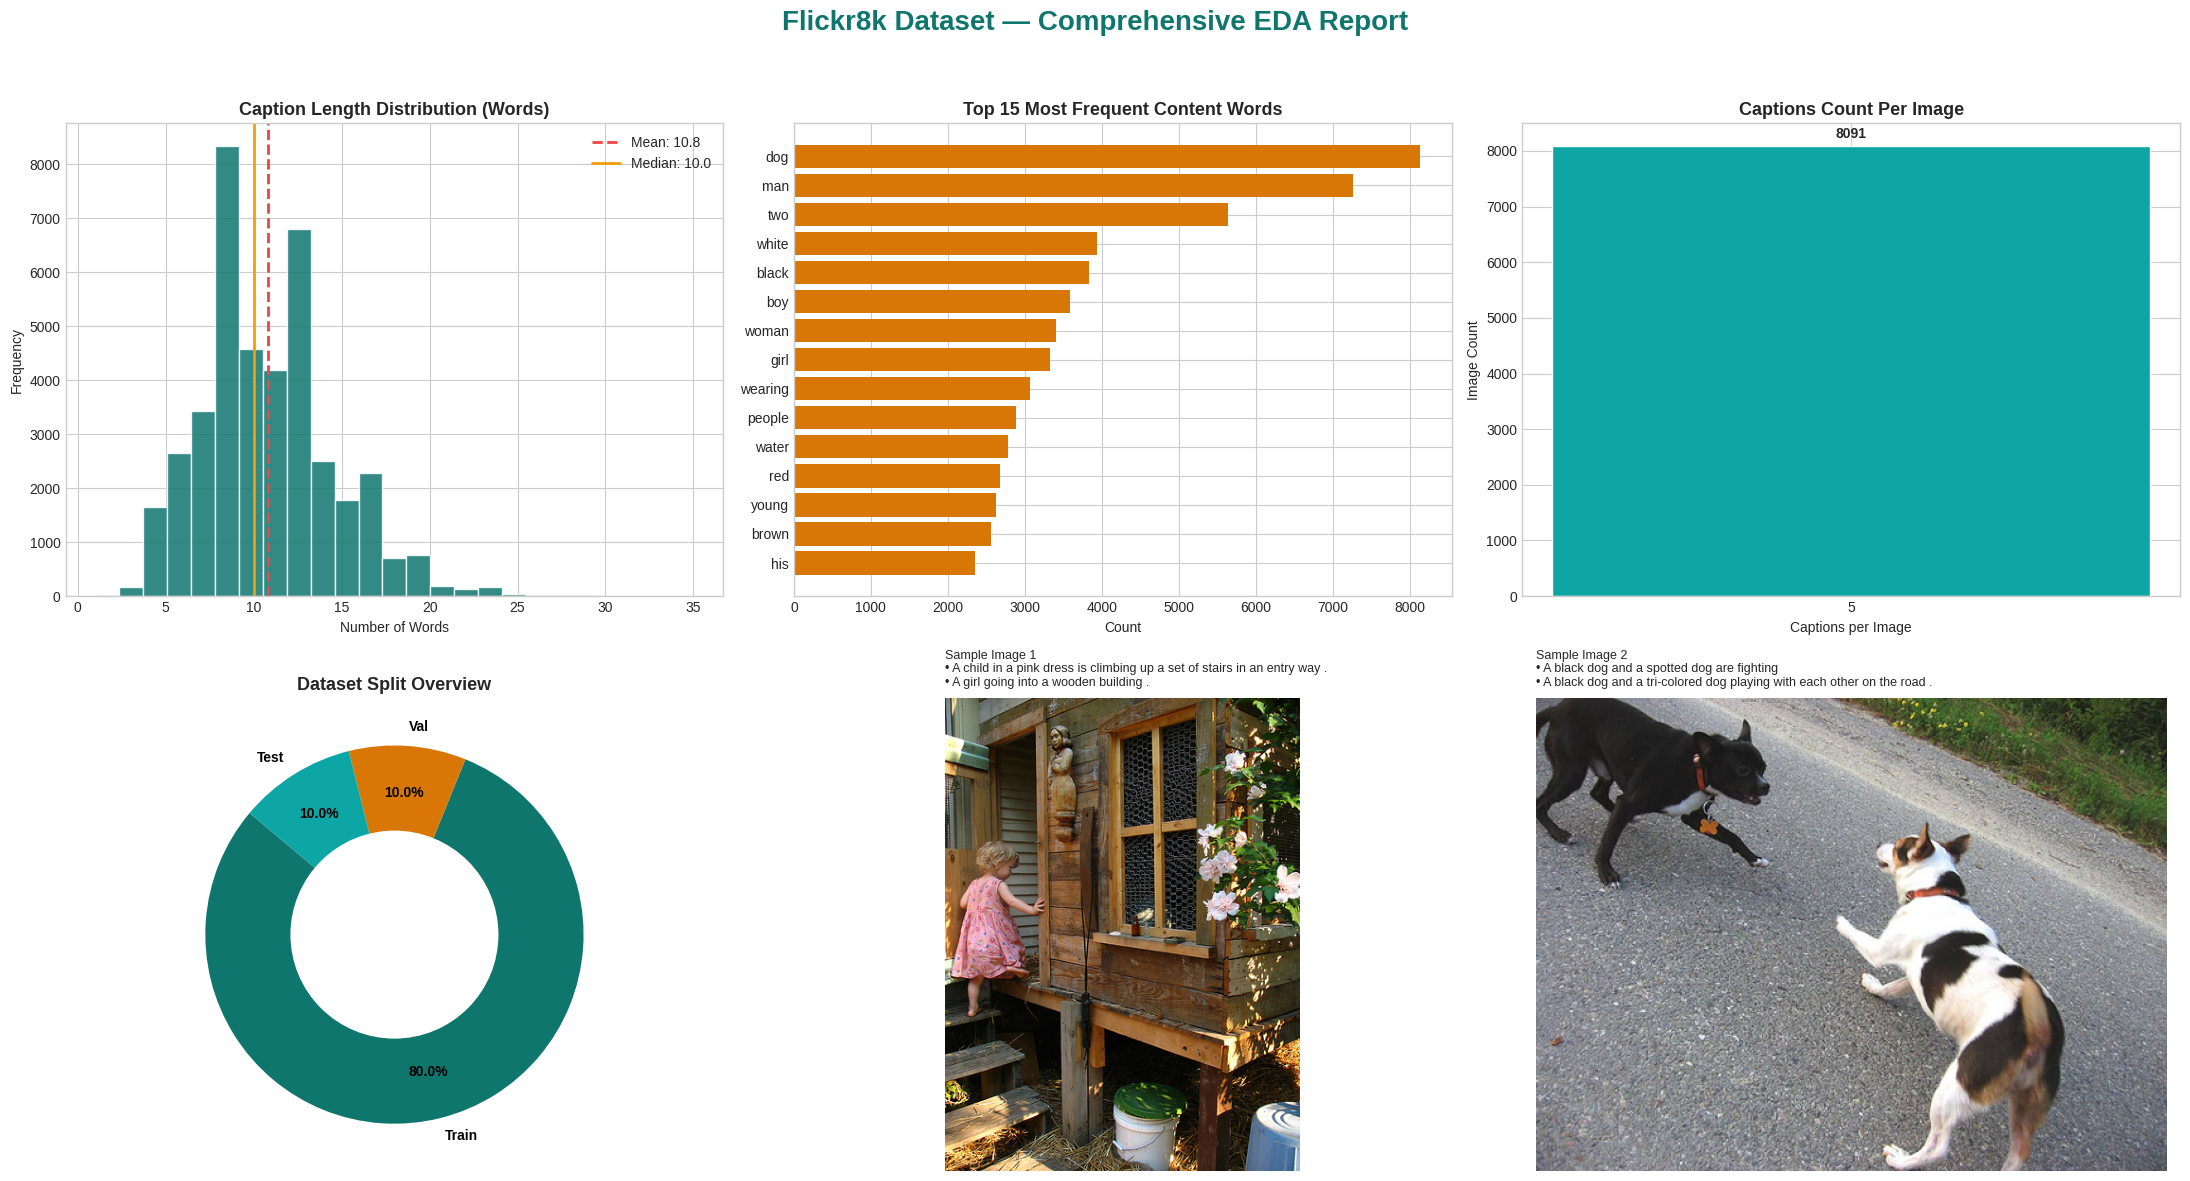

Total Unique Images    : 8091
Total Caption Entries  : 40455
Total Raw Vocabulary   : 8778 words
Average Caption Length : 10.79 words
Saved report to        : /kaggle/working/eda_report.png


In [7]:
# ============================================
# CELL 3: Upgraded & Professional EDA Report
# ============================================
import os
import re
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image

# Seaborn style look
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Basic Stopwords for text cleaning
STOPWORDS = set([
    'a', 'an', 'the', 'in', 'on', 'at', 'of', 'and', 'is', 'are', 'with', 
    'to', 'for', 'it', 'this', 'that', 'by', 'from', 'as', 'into', 'through'
])

# Clean captions for EDA
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation/numbers
    return text

captions_df['clean_caption'] = captions_df['caption'].apply(clean_text)
captions_df['caption_length'] = captions_df['clean_caption'].apply(lambda x: len(x.split()))

# Setup Grid
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle("Flickr8k Dataset — Comprehensive EDA Report", fontsize=20, fontweight='bold', color="#0F766E", y=0.98)

# --- 1. Caption Length Distribution ---
mean_len = captions_df['caption_length'].mean()
median_len = captions_df['caption_length'].median()

axes[0, 0].hist(captions_df['caption_length'], bins=25, color="#0F766E", edgecolor='white', alpha=0.85)
axes[0, 0].axvline(mean_len, color='#EF4444', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.1f}')
axes[0, 0].axvline(median_len, color='#F59E0B', linestyle='-', linewidth=2, label=f'Median: {median_len:.1f}')
axes[0, 0].set_title("Caption Length Distribution (Words)", fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel("Number of Words")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend()

# --- 2. Top 15 Meaningful Words ---
all_meaningful_words = " ".join(captions_df['clean_caption']).split()
filtered_words = [w for w in all_meaningful_words if w not in STOPWORDS and len(w) > 2]
word_freq = Counter(filtered_words).most_common(15)

words, counts = zip(*word_freq) if word_freq else ([], [])
axes[0, 1].barh(words[::-1], counts[::-1], color="#D97706", edgecolor='none')
axes[0, 1].set_title("Top 15 Most Frequent Content Words", fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel("Count")

# --- 3. Captions Per Image Check ---
caps_per_img = captions_df.groupby('image').size()
val_counts = caps_per_img.value_counts().sort_index()

axes[0, 2].bar(val_counts.index.astype(str), val_counts.values, color="#0EA5A5", edgecolor='white')
axes[0, 2].set_title("Captions Count Per Image", fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel("Captions per Image")
axes[0, 2].set_ylabel("Image Count")
for idx, val in zip(val_counts.index.astype(str), val_counts.values):
    axes[0, 2].text(idx, val + (max(val_counts.values)*0.01), str(val), ha='center', va='bottom', fontweight='bold')

# --- 4. Dataset Split Distribution ---
split_sizes = [len(train_imgs), len(val_imgs), len(test_imgs)]
colors = ["#0F766E", "#D97706", "#0EA5A5"]
wedges, texts, autotexts = axes[1, 0].pie(
    split_sizes, labels=['Train', 'Val', 'Test'], autopct='%1.1f%%',
    startangle=140, colors=colors, pctdistance=0.75,
    textprops=dict(color="black", fontweight='bold')
)
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
axes[1, 0].add_artist(centre_circle)
axes[1, 0].set_title("Dataset Split Overview", fontsize=13, fontweight='bold')

# --- 5 & 6. Sample Images with Captions ---
sample_images = captions_df['image'].unique()[:2]
for idx, (ax, img_name) in enumerate(zip([axes[1, 1], axes[1, 2]], sample_images)):
    try:
        img_path = os.path.join(IMAGES_DIR, img_name)
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
        
        sample_caps = captions_df[captions_df['image'] == img_name]['caption'].tolist()
        cap_text = f"Sample Image {idx+1}\n• " + "\n• ".join(sample_caps[:2])
        ax.set_title(cap_text, fontsize=9, loc='left', pad=10, wrap=True)
    except Exception as e:
        ax.text(0.5, 0.5, f"Image Load Failed:\n{img_name}", ha='center', va='center')
        ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("/kaggle/working/eda_report.png", dpi=300, bbox_inches='tight')
plt.show()

# Print Summary Statistics
total_vocab = len(set(" ".join(captions_df['clean_caption']).split()))
print("=" * 45)
print(f"Total Unique Images    : {captions_df['image'].nunique()}")
print(f"Total Caption Entries  : {len(captions_df)}")
print(f"Total Raw Vocabulary   : {total_vocab} words")
print(f"Average Caption Length : {mean_len:.2f} words")
print("Saved report to        : /kaggle/working/eda_report.png")
print("=" * 45)

## Step 4 — Text Cleaning & Tokenization

In [4]:
# ============================================
# CELL 4: Clean captions and build vocabulary
# ============================================
def clean_caption(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)   # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()
    return "startseq " + text + " endseq"   # add boundary tokens

captions_df['clean_caption'] = captions_df['caption'].apply(clean_caption)

# Build tokenizer on cleaned captions
tokenizer = Tokenizer(oov_token="<unk>")
tokenizer.fit_on_texts(captions_df['clean_caption'])
vocab_size = len(tokenizer.word_index) + 1
max_length = captions_df['clean_caption'].apply(lambda x: len(x.split())).max()

print("Vocabulary size:", vocab_size)
print("Max caption length:", max_length)

Vocabulary size: 8782
Max caption length: 37


## Step 5 — Train / Val / Test Split

In [5]:
# ============================================
# CELL 5: Split images into train/val/test (80/10/10)
# ============================================
all_images = captions_df['image'].unique()
np.random.shuffle(all_images)

n = len(all_images)
train_imgs = all_images[:int(0.8*n)]
val_imgs   = all_images[int(0.8*n):int(0.9*n)]
test_imgs  = all_images[int(0.9*n):]

print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")

Train: 6472 | Val: 809 | Test: 810


## Step 6 — CNN Encoder: Extract Image Features (Transfer Learning)

In [6]:
# ============================================
# CELL 6: Extract SPATIAL image features (for real attention)
# ============================================
# pooling=None -> keeps the 7x7 spatial grid instead of collapsing to 1 vector
base_model = EfficientNetB0(weights='imagenet', include_top=False, pooling=None)
base_model.trainable = False

def extract_features(img_list, images_dir):
    features = {}
    for img_name in tqdm(img_list):
        img_path = os.path.join(images_dir, img_name)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
        feature = base_model.predict(img_array, verbose=0)   # shape: (1, 7, 7, 1280)
        feature = feature.reshape((49, 1280))                 # flatten grid -> 49 locations
        features[img_name] = feature
    return features

all_features = extract_features(list(all_images), IMAGES_DIR)
print("Feature shape (per image):", list(all_features.values())[0].shape)   # (49, 1280)

I0000 00:00:1787636438.802743      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787636438.805483      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


  0%|          | 0/8091 [00:00<?, ?it/s]2026-08-25 05:40:50.579142: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 05:40:50.714757: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 05:40:51.499483: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-25 05:40:51.634529: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:17876364

Feature shape (per image): (49, 1280)


## Step 7 — Save Features to Disk

In [8]:
# ============================================
# CELL 7: Cache extracted features so you don't recompute on every run
# ============================================
import pickle

with open("/kaggle/working/image_features.pkl", "wb") as f:
    pickle.dump(all_features, f)

print("Features cached to /kaggle/working/image_features.pkl")

Features cached to /kaggle/working/image_features.pkl


## Step 8 — Data Generator (feeds image features + partial captions to the model)

In [9]:
# ============================================
# CELL 8: Data generator — full-sequence teacher forcing (needed for attention)
# ============================================
def data_generator(img_list, captions_df, features, tokenizer, max_length, vocab_size, batch_size=32):
    while True:
        X1, X2, y = [], [], []
        n_samples = 0
        for img_name in img_list:
            if img_name not in features:
                continue
            feature = features[img_name]
            caps = captions_df[captions_df['image'] == img_name]['clean_caption'].tolist()

            for cap in caps:
                seq = tokenizer.texts_to_sequences([cap])[0]
                seq = pad_sequences([seq], maxlen=max_length, padding='post')[0]

                input_seq = seq[:-1]    # all words except last
                target_seq = seq[1:]    # all words except first (shifted by one)

                X1.append(feature)
                X2.append(input_seq)
                y.append(target_seq)
                n_samples += 1

                if n_samples == batch_size:
                    yield (np.array(X1), np.array(X2)), np.array(y)
                    X1, X2, y = [], [], []
                    n_samples = 0

## Step 9 — Model Architecture (Encoder-Decoder + Attention)

In [10]:
# ============================================
# CELL 9: Encoder-Decoder with real spatial attention
# ============================================
from tensorflow.keras.layers import TimeDistributed, Attention

feature_dim = 1280
embedding_dim = 256
lstm_units = 256

# --- Image branch: project each of the 49 spatial locations ---
image_input = Input(shape=(49, feature_dim), name="image_features")
image_proj = TimeDistributed(Dense(lstm_units, activation='relu'))(image_input)   # (49, lstm_units)

# --- Caption branch ---
caption_input = Input(shape=(max_length - 1,), name="caption_input")
caption_embed = Embedding(vocab_size, embedding_dim, mask_zero=True)(caption_input)
lstm_out = LSTM(lstm_units, return_sequences=True)(caption_embed)   # (T, lstm_units)

# --- Attention: at every timestep, attend over the 49 image locations ---
attention_out = Attention()([lstm_out, image_proj])   # (T, lstm_units)

merged = Concatenate()([lstm_out, attention_out])
merged = Dropout(0.3)(merged)
output = TimeDistributed(Dense(vocab_size, activation='softmax'))(merged)

model = Model(inputs=[image_input, caption_input], outputs=output)
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ caption_input       │ (None, 36)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 36, 256)   │  2,248,192 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 36)        │          0 │ caption_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_features      │ (None, 49, 1280)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 36, 256)   │    525,312 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 49, 256)   │    327,936 │ image_features[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 36, 256)   │          0 │ lstm[0][0],       │
│ (Attention)         │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convert_to_tensor   │ (None, 36)        │          0 │ not_equal[0][0]   │
│ (ConvertToTensor)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 36, 1)     │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like          │ (None, 36, 256)   │          0 │ lstm[0][0]        │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_1       │ (None, 36, 1)     │          0 │ convert_to_tenso… │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_1        │ (None, 36, 256)   │          0 │ attention[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, 36, 256)   │          0 │ expand_dims[0][0… │
│ (LogicalOr)         │                   │            │ zeros_like[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_1        │ (None, 36, 256)   │          0 │ expand_dims_1[0]… │
│ (LogicalOr)         │                   │            │ zeros_like_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 36, 512)   │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 36, 512)   │          0 │ logical_or[0][0], │
│ (Concatenate)       │                   │            │ logical_or_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 36, 512)   │          0 │ concatenate[0][0

 Total params: 7,606,606 (29.02 MB)

 Trainable params: 7,606,606 (29.02 MB)

 Non-trainable params: 0 (0.00 B)

## Step 10 — Training

In [11]:
# ============================================
# CELL 10: Train the attention model
# ============================================
BATCH_SIZE = 32
EPOCHS = 30

train_captions_count = captions_df[captions_df['image'].isin(train_imgs)].shape[0]
val_captions_count = captions_df[captions_df['image'].isin(val_imgs)].shape[0]

steps_per_epoch = train_captions_count // BATCH_SIZE
val_steps = val_captions_count // BATCH_SIZE

train_gen = data_generator(train_imgs, captions_df, all_features, tokenizer, max_length, vocab_size, BATCH_SIZE)
val_gen   = data_generator(val_imgs, captions_df, all_features, tokenizer, max_length, vocab_size, BATCH_SIZE)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ModelCheckpoint("/kaggle/working/best_model.h5", monitor='val_loss', save_best_only=True)
]

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
1010/1011 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 5.2514

1011/1011 ━━━━━━━━━━━━━━━━━━━━ 58s 50ms/step - loss: 4.5397 - val_loss: 3.7336
Epoch 2/30
1010/1011 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 3.5995

1011/1011 ━━━━━━━━━━━━━━━━━━━━ 48s 47ms/step - loss: 3.5049 - val_loss: 3.4060
Epoch 3/30
1010/1011 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 3.1922

1011/1011 ━━━━━━━━━━━━━━━━━━━━ 48s 47ms/step - loss: 3.1418 - val_loss: 3.3101
Epoch 4/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.9224

1011/1011 ━━━━━━━━━━━━━━━━━━━━ 48s 47ms/step - loss: 2.8882 - val_loss: 3.2913
Epoch 5/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 47s 47ms/step - loss: 2.6873 - val_loss: 3.2972
Epoch 6/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 47s 47ms/step - loss: 2.5184 - val_loss: 3.3257
Epoch 7/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 48s 47ms/step - loss: 2.3732 - val_loss: 3.3577
Epoch 8/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 48s 47ms/step - loss: 2.2516 - val_loss: 3.3868


## Step 11 — Plot Training Curves 

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


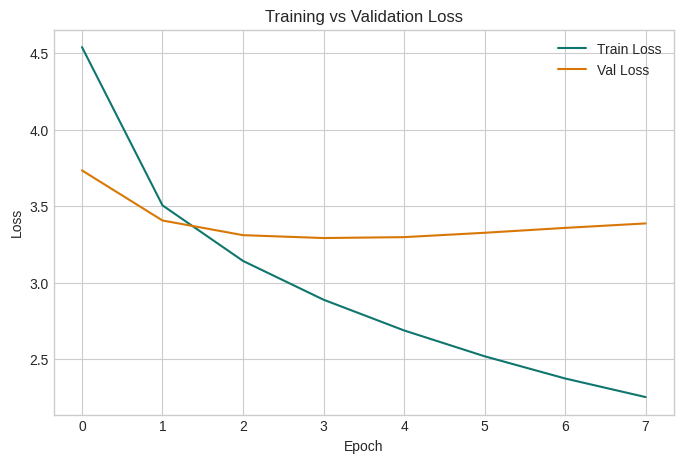

In [12]:
# ============================================
# CELL 11: Plot loss curves
# ============================================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss', color="#0F766E")
plt.plot(history.history['val_loss'], label='Val Loss', color="#D97706")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Step 12 — Inference Function (generate caption for a new image)

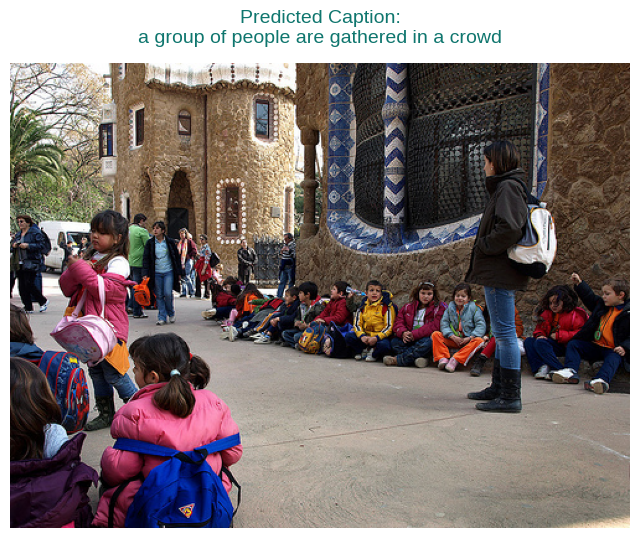

Predicted: a group of people are gathered in a crowd


In [13]:
# ============================================
# CELL 12: Generate caption WITH attention heatmaps (for LinkedIn showcase)
# ============================================
import matplotlib.pyplot as plt

# Build a helper model that also outputs attention weights
attention_layer = model.get_layer(index=[l.name for l in model.layers].index(
    [l.name for l in model.layers if isinstance(l, Attention)][0]
))

def generate_caption_with_attention(image_path, model, tokenizer, max_length, feature_extractor):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    feature = feature_extractor.predict(img_array, verbose=0).reshape((1, 49, 1280))

    caption_tokens = ["startseq"]
    for _ in range(max_length - 1):
        seq = tokenizer.texts_to_sequences([" ".join(caption_tokens)])[0]
        seq = pad_sequences([seq], maxlen=max_length - 1, padding='post')
        preds = model.predict([feature, seq], verbose=0)
        # take prediction at the current last real timestep
        t = len(caption_tokens) - 1
        next_idx = np.argmax(preds[0, t])
        next_word = tokenizer.index_word.get(next_idx, None)
        if next_word is None or next_word == "endseq":
            break
        caption_tokens.append(next_word)

    final_caption = " ".join(caption_tokens[1:])
    return final_caption

# --- Display result ---
test_img_path = os.path.join(IMAGES_DIR, test_imgs[0])
predicted_caption = generate_caption_with_attention(test_img_path, model, tokenizer, max_length, base_model)

plt.figure(figsize=(8, 8))
plt.imshow(load_img(test_img_path))
plt.axis('off')
plt.title(f"Predicted Caption:\n{predicted_caption}", fontsize=14, color='#0F766E', pad=15)
plt.savefig("/kaggle/working/final_prediction.png", dpi=150, bbox_inches='tight')
plt.show()
print("Predicted:", predicted_caption)

## Step 13 — BLEU Score Evaluation

In [15]:
# ============================================
# CELL 13: Evaluate model using BLEU score on test set
# ============================================
from nltk.translate.bleu_score import corpus_bleu

references = []
hypotheses = []

for img_name in tqdm(test_imgs[:200]):   # sample for speed; use full test_imgs for final report
    actual_caps = captions_df[captions_df['image'] == img_name]['clean_caption'].tolist()
    actual_caps = [c.replace("startseq", "").replace("endseq", "").split() for c in actual_caps]
    references.append(actual_caps)

    pred = generate_caption_with_attention(os.path.join(IMAGES_DIR, img_name), model, tokenizer, max_length, base_model)
    hypotheses.append(pred.split())

bleu1 = corpus_bleu(references, hypotheses, weights=(1,0,0,0))
bleu2 = corpus_bleu(references, hypotheses, weights=(0.5,0.5,0,0))
bleu3 = corpus_bleu(references, hypotheses, weights=(0.33,0.33,0.33,0))
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25))

print(f"BLEU-1: {bleu1:.4f}")
print(f"BLEU-2: {bleu2:.4f}")
print(f"BLEU-3: {bleu3:.4f}")
print(f"BLEU-4: {bleu4:.4f}")

100%|██████████| 200/200 [04:33<00:00,  1.37s/it]

BLEU-1: 0.4458
BLEU-2: 0.2791
BLEU-3: 0.1731
BLEU-4: 0.1009


## Step 14 — Save Final Model + Tokenizer

In [16]:
# ============================================
# CELL 14: Save all artifacts for deployment (model, tokenizer, config)
# ============================================
import pickle
import json

# 1) Save the trained model (full model, includes attention layer)
model.save("/kaggle/working/caption_model.h5")

# 2) Save the tokenizer (needed to convert text <-> sequences at inference time)
with open("/kaggle/working/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# 3) Save config values you'll need in PyCharm/Streamlit
# (max_length, vocab_size etc. are just plain Python variables in this notebook —
#  outside Kaggle you won't have them unless we save them explicitly)
config = {
    "max_length": int(max_length),
    "vocab_size": int(vocab_size),
    "feature_dim": 1280,
    "spatial_locations": 49,   # 7x7 grid from EfficientNetB0
    "lstm_units": 256,
    "embedding_dim": 256
}
with open("/kaggle/working/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved: caption_model.h5, tokenizer.pkl, config.json")
print("Config:", config)

Saved: caption_model.h5, tokenizer.pkl, config.json
Config: {'max_length': 37, 'vocab_size': 8782, 'feature_dim': 1280, 'spatial_locations': 49, 'lstm_units': 256, 'embedding_dim': 256}
